# Benchmark comparison
This notebook compares model results across benchmark CSVs in `runs/benchmarks/`

In [55]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid', context='talk')

SUMMARY_DIR_CANDIDATES = [
    Path('../reports/benchmarks/summary'),
    Path('2d-detection/reports/benchmarks/summary'),
    Path('reports/benchmarks/summary'),
]
SUMMARY_DIR = next((path for path in SUMMARY_DIR_CANDIDATES if path.exists()), SUMMARY_DIR_CANDIDATES[0])


In [56]:
# Load all benchmark summary CSVs from both frameworks.
summary_files = sorted(SUMMARY_DIR.rglob('summary_*.csv'))
if not summary_files:
    raise FileNotFoundError(f'No summary CSV files found under {SUMMARY_DIR.resolve()}')


def summary_name_from_path(path: Path) -> str:
    return path.stem.replace('summary_', '')


frames = []
for csv_path in summary_files:
    df = pd.read_csv(csv_path)
    summary_name = summary_name_from_path(csv_path)
    benchmark_name = summary_name.split('_', 1)[1] if '_' in summary_name else summary_name

    if 'model' not in df.columns:
        df['model'] = pd.NA
    if 'source_model' not in df.columns:
        df['source_model'] = pd.NA
    if 'checkpoint' not in df.columns:
        df['checkpoint'] = pd.NA

    df['framework'] = csv_path.parent.name
    df['summary_name'] = summary_name
    df['benchmark_name'] = benchmark_name
    frames.append(df)

bench = pd.concat(frames, ignore_index=True, sort=False)

for col in ['map50_95', 'inf_time_per_frame_ms']:
    bench[col] = pd.to_numeric(bench[col], errors='coerce')

bench = bench.dropna(subset=['map50_95', 'inf_time_per_frame_ms']).copy()
bench[['framework', 'benchmark_name', 'model', 'source_model', 'map50_95', 'inf_time_per_frame_ms']].head(10)


,framework,benchmark_name,model,source_model,map50_95,inf_time_per_frame_ms
0,mmdetection,coco2017_filtered,faster-rcnn_r50_fpn_coco2017_filtered,NaN,0.521,41.822
1,mmdetection,coco2017_filtered_to_zedrgb,faster-rcnn_r50_fpn_coco2017_filtered_to_zedrgb,NaN,0.666,28.324
2,mmdetection,coco2017_filtered_without_finetuning,faster-rcnn_r50_caffe_fpn_ms_coco-person_coco2...,NaN,0.564,28.225
3,mmdetection,fieldsafepedestrian,faster-rcnn_r50_fpn_fieldsafepedestrian,NaN,0.574,31.656
4,mmdetection,fieldsafepedestrian_from_scratch,faster-rcnn_r50_scratch_gn_all_fieldsafepedest...,NaN,0.594,40.559
5,mmdetection,fieldsafepedestrian_to_zedrgb,faster-rcnn_r50_fpn_fieldsafepedestrian_to_zedrgb,NaN,0.062,29.903
6,mmdetection,fieldsafepedestrian_without_finetuning,faster-rcnn_r50_caffe_fpn_ms_coco-person_field...,NaN,0.553,29.130
7,mmdetection,fisheye,faster-rcnn_r50_fpn_fisheye,NaN,0.738,31.015
8,mmdetection,fisheye,faster-rcnn_r50_fpn_dcn_fisheye,NaN,0.754,36.848
9,mmdetection,fisheye_to_coco2017_filtered,faster-rcnn_r50_fpn_fisheye_to_coco2017_filtered,NaN,0.058,29.477


In [57]:
# Normalize labels so the charts read like a benchmark story.
DATASET_LABELS = {
    'coco2017_filtered': 'COCO filtered',
    'fieldsafepedestrian': 'FieldSafePedestrian',
    'fisheye': 'Fisheye',
    'kitti_filtered': 'KITTI filtered',
    'zedrgb': 'ZED RGB',
}

SCRATCHLIKE_LABEL = 'scratch / no pretrained weights'


def pretty_dataset(name: str) -> str:
    return DATASET_LABELS.get(name, name.replace('_', ' ').title())



def story_group(name: str) -> str:
    if '_to_' in name:
        return 'transfer'
    if any(tag in name for tag in ['without_finetuning', 'without_pretrained', 'from_scratch']):
        return 'ablation'
    return 'in_domain'



def benchmark_display(name: str) -> str:
    if '_to_' in name:
        source, target = name.split('_to_', 1)
        return f'{pretty_dataset(source)} -> {pretty_dataset(target)}'
    if name.endswith('_without_finetuning'):
        base = name[: -len('_without_finetuning')]
        return f'{pretty_dataset(base)} | no fine-tuning'
    if name.endswith('_without_pretrained'):
        base = name[: -len('_without_pretrained')]
        return f'{pretty_dataset(base)} | {SCRATCHLIKE_LABEL}'
    if name.endswith('_from_scratch'):
        base = name[: -len('_from_scratch')]
        return f'{pretty_dataset(base)} | {SCRATCHLIKE_LABEL}'
    return pretty_dataset(name)



def simplify_model_label(row: pd.Series) -> str:
    framework = row['framework']
    raw_model = row.get('model')
    source_model = row.get('source_model')
    checkpoint = row.get('checkpoint')

    if framework == 'ultralytics':
        candidate = raw_model if pd.notna(raw_model) else source_model
        candidate = '' if pd.isna(candidate) else str(candidate)
        stem = Path(candidate).stem if candidate else ''
        stem = re.sub(r'\d+$', '', stem)
        stem = {
            'yolov8s': 'YOLOv8s',
            'yolo11s': 'YOLO11s',
        }.get(stem, stem.upper() if stem else 'YOLO')
        if isinstance(raw_model, str) and raw_model.endswith('.yaml'):
            stem = f'{stem} scratch init'
        return f'Ultralytics {stem}'

    model_name = '' if pd.isna(raw_model) else str(raw_model)
    if 'scratch' in model_name:
        return 'MMDetection Faster R-CNN scratch'
    if 'coco-person' in model_name:
        return 'MMDetection Faster R-CNN COCO-person'
    if 'dcn' in model_name:
        return 'MMDetection Faster R-CNN + DCN'
    if checkpoint and pd.notna(checkpoint):
        return 'MMDetection Faster R-CNN'
    return 'MMDetection Faster R-CNN'


bench['story_group'] = bench['benchmark_name'].apply(story_group)
bench['benchmark_display'] = bench['benchmark_name'].apply(benchmark_display)
bench['series_label'] = bench.apply(simplify_model_label, axis=1)

overview = (
    bench[
        ['story_group', 'benchmark_display', 'series_label', 'map50_95', 'inf_time_per_frame_ms']
    ]
    .sort_values(['story_group', 'benchmark_display', 'map50_95'], ascending=[True, True, False])
    .reset_index(drop=True)
)
display(overview)


,story_group,benchmark_display,series_label,map50_95,inf_time_per_frame_ms
0,ablation,COCO filtered | no fine-tuning,Ultralytics YOLO11s,0.588532,1.975
1,ablation,COCO filtered | no fine-tuning,Ultralytics YOLOv8s,0.577360,1.916
2,ablation,COCO filtered | no fine-tuning,MMDetection Faster R-CNN COCO-person,0.564000,28.225
3,ablation,FieldSafePedestrian | no fine-tuning,MMDetection Faster R-CNN COCO-person,0.553000,29.130
4,ablation,FieldSafePedestrian | no fine-tuning,Ultralytics YOLOv8s,0.510111,4.511
5,ablation,FieldSafePedestrian | no fine-tuning,Ultralytics YOLO11s,0.508764,2.843
6,ablation,FieldSafePedestrian | scratch / no pretrained ...,MMDetection Faster R-CNN scratch,0.594000,40.559
7,ablation,FieldSafePedestrian | scratch / no pretrained ...,Ultralytics YOLOv8s scratch init,0.474216,3.226
8,ablation,FieldSafePedestrian | scratch / no pretrained ...,Ultralytics YOLO11s scratch init,0.463111,4.040
9,ablation,Fisheye | no fine-tuning,Ultralytics YOLO11s,0.729187,1.976


In [58]:
# Plot helpers: one paired bar chart per story group.
GROUP_TITLES = {
    'in_domain': 'In-domain fine-tuning',
    'transfer': 'Cross-dataset transfer',
    'ablation': 'Training ablations',
}


def annotate_horizontal_bars(ax, fmt: str) -> None:
    for container in ax.containers:
        values = []
        for bar in container:
            width = bar.get_width()
            values.append(fmt.format(width) if width == width and width > 0 else '')
        ax.bar_label(container, labels=values, padding=4, fontsize=9)



def finalize_figure(fig, handles, labels, title: str) -> None:
    if handles:
        fig.legend(
            handles,
            labels,
            title=title,
            loc='center left',
            bbox_to_anchor=(0.83, 0.5),
            frameon=True,
            borderaxespad=0.0,
        )
    fig.tight_layout(rect=(0, 0, 0.8, 1))



def plot_story_group(data: pd.DataFrame, group_name: str) -> None:
    subset = data[data['story_group'] == group_name].copy()
    if subset.empty:
        print(f'No rows available for group: {group_name}')
        return

    order = (
        subset.groupby('benchmark_display')['map50_95']
        .max()
        .sort_values(ascending=False)
        .index
        .tolist()
    )
    hue_order = (
        subset.groupby('series_label')['map50_95']
        .max()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    fig_height = max(6, 0.8 * len(order) + 1.5)
    fig, axes = plt.subplots(1, 2, figsize=(22, fig_height), sharey=True)

    sns.barplot(
        data=subset,
        y='benchmark_display',
        x='map50_95',
        hue='series_label',
        order=order,
        hue_order=hue_order,
        orient='h',
        ax=axes[0],
    )
    sns.barplot(
        data=subset,
        y='benchmark_display',
        x='inf_time_per_frame_ms',
        hue='series_label',
        order=order,
        hue_order=hue_order,
        orient='h',
        ax=axes[1],
    )

    axes[0].set_title(f'{GROUP_TITLES[group_name]}: mAP@50-95')
    axes[0].set_xlabel('mAP@50-95')
    axes[0].set_ylabel('')
    axes[0].set_xlim(0, min(1.0, subset['map50_95'].max() * 1.15))

    axes[1].set_title(f'{GROUP_TITLES[group_name]}: inference time per frame')
    axes[1].set_xlabel('Inference time per frame (ms)')
    axes[1].set_ylabel('')
    axes[1].set_xlim(0, subset['inf_time_per_frame_ms'].max() * 1.15)

    for ax in axes:
        ax.grid(axis='x', linestyle='--', alpha=0.35)

    annotate_horizontal_bars(axes[0], '{:.3f}')
    annotate_horizontal_bars(axes[1], '{:.2f} ms')

    legend = axes[0].get_legend()
    handles, labels = axes[0].get_legend_handles_labels()
    if legend is not None:
        legend.remove()
    legend = axes[1].get_legend()
    if legend is not None:
        legend.remove()

    finalize_figure(fig, handles, labels, 'Model family')
    plt.show()


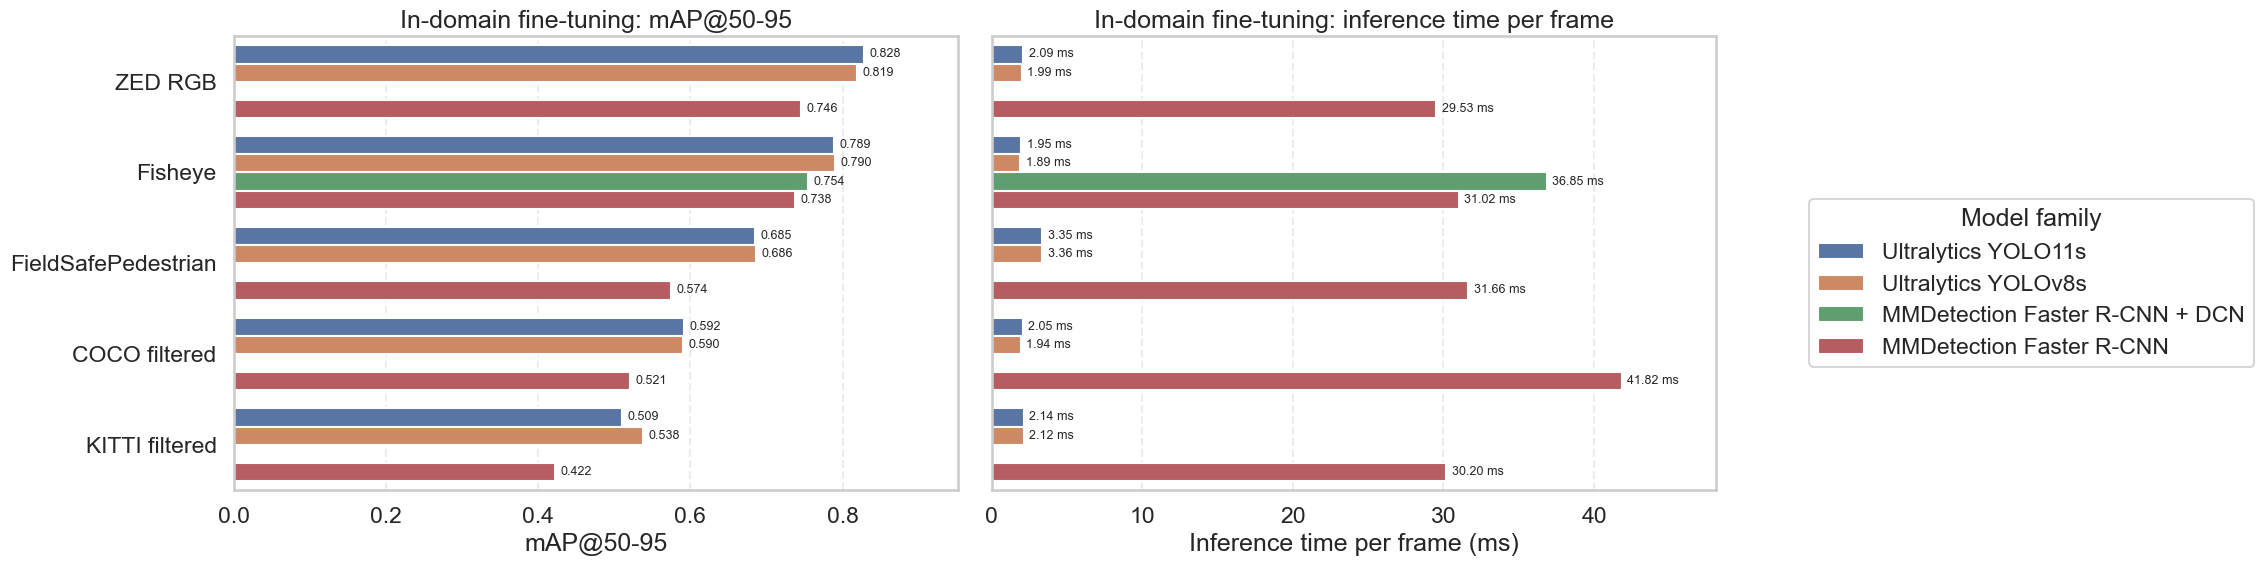

In [59]:
plot_story_group(bench, 'in_domain')


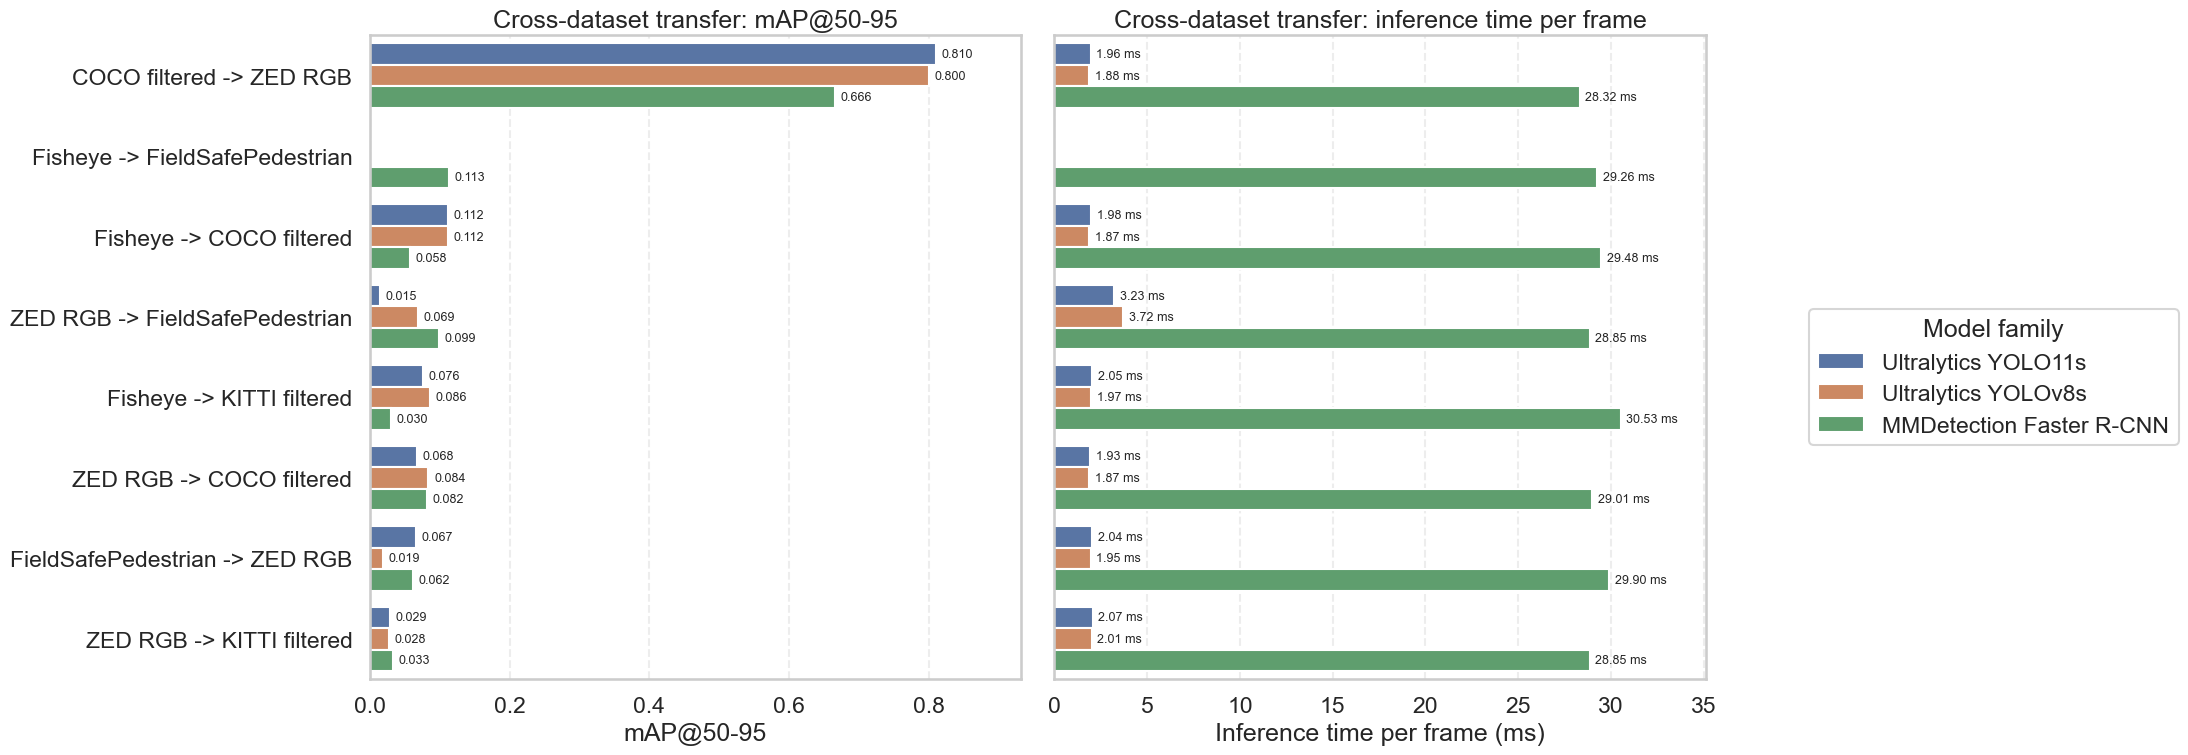

In [60]:
plot_story_group(bench, 'transfer')


### Story framing
These charts focus only on `mAP@50-95` and inference time per frame. The benchmark files are grouped into three stories: in-domain fine-tuning, cross-dataset transfer, and training ablations.

Within the ablation story, `from scratch` and `no pretrained weights` are intentionally grouped together because they both represent training without pretrained initialization.

For paper writing, treat these charts as **benchmark outcomes for framework-model families**, not as strictly controlled backbone-only ablations. The summary files may differ in image size, initialization, transfer protocol, and framework-specific inference pipelines.


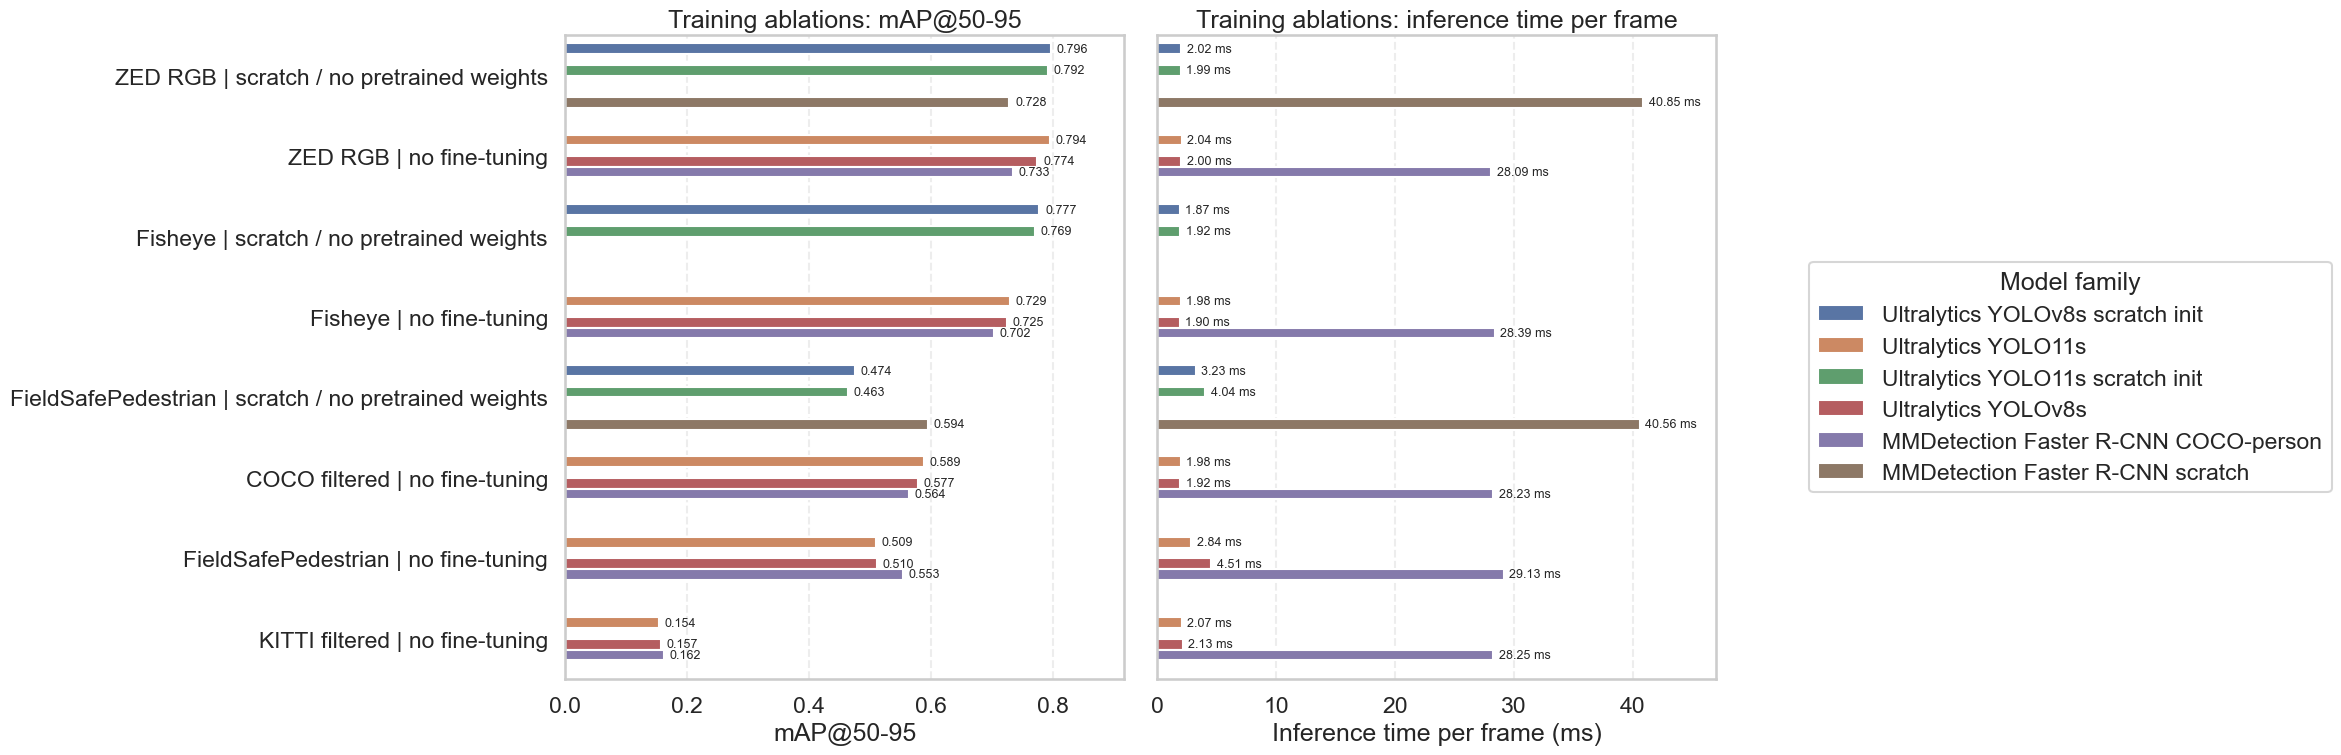

In [61]:
plot_story_group(bench, 'ablation')


In [62]:
# # One winner per benchmark: highest mAP@50-95, with latency as the tiebreaker.
# best_per_benchmark = (
#     bench.sort_values(['benchmark_display', 'map50_95', 'inf_time_per_frame_ms'], ascending=[True, False, True])
#     .drop_duplicates(subset=['benchmark_display'])
#     .copy()
# )

# winner_order = best_per_benchmark.sort_values('map50_95', ascending=False)['benchmark_display'].tolist()
# fig, axes = plt.subplots(1, 2, figsize=(22, max(6, 0.55 * len(winner_order) + 1.5)), sharey=True)

# sns.barplot(
#     data=best_per_benchmark,
#     y='benchmark_display',
#     x='map50_95',
#     hue='story_group',
#     dodge=False,
#     order=winner_order,
#     orient='h',
#     ax=axes[0],
# )
# sns.barplot(
#     data=best_per_benchmark,
#     y='benchmark_display',
#     x='inf_time_per_frame_ms',
#     hue='story_group',
#     dodge=False,
#     order=winner_order,
#     orient='h',
#     ax=axes[1],
# )

# axes[0].set_title('Best run in each benchmark: mAP@50-95')
# axes[0].set_xlabel('mAP@50-95')
# axes[0].set_ylabel('')
# axes[0].set_xlim(0, min(1.0, best_per_benchmark['map50_95'].max() * 1.15))

# axes[1].set_title('Best run in each benchmark: inference time per frame')
# axes[1].set_xlabel('Inference time per frame (ms)')
# axes[1].set_ylabel('')
# axes[1].set_xlim(0, best_per_benchmark['inf_time_per_frame_ms'].max() * 1.15)


# for ax in axes:
#     ax.grid(axis='x', linestyle='--', alpha=0.35)

# annotate_horizontal_bars(axes[0], '{:.3f}')
# annotate_horizontal_bars(axes[1], '{:.2f} ms')

# legend = axes[0].get_legend()
# handles, labels = axes[0].get_legend_handles_labels()
# if legend is not None:
#     legend.remove()
# legend = axes[1].get_legend()
# if legend is not None:
#     legend.remove()

# label_map = {
#     'in_domain': 'In-domain',
#     'transfer': 'Transfer',
#     'ablation': 'Ablation',
# }
# finalize_figure(fig, handles, [label_map.get(label, label) for label in labels], 'Benchmark group')
# plt.show()

# display(
#     best_per_benchmark[
#         ['benchmark_display', 'series_label', 'story_group', 'map50_95', 'inf_time_per_frame_ms']
#     ].sort_values('map50_95', ascending=False)
# )


### Interpretation
The next cell computes benchmark-level evidence directly from the loaded CSV summaries. It is meant to support rigorous writing: exact winner counts, median gaps, and explicit caveats about how fair the comparison is.


In [63]:
# Benchmark-level evidence for paper writing.
best_per_benchmark = (
    bench.sort_values(['benchmark_display', 'map50_95', 'inf_time_per_frame_ms'], ascending=[True, False, True])
    .drop_duplicates(subset=['benchmark_display'])
    .copy()
)

framework_run_summary = (
    bench.groupby('framework')[['map50_95', 'inf_time_per_frame_ms']]
    .median()
    .rename(columns={
        'map50_95': 'median_map50_95_over_all_runs',
        'inf_time_per_frame_ms': 'median_inference_ms_over_all_runs',
    })
)
display(framework_run_summary.round(3))

winner_group_summary = (
    best_per_benchmark.groupby('story_group')[['map50_95', 'inf_time_per_frame_ms']]
    .median()
    .rename(columns={
        'map50_95': 'median_winner_map50_95',
        'inf_time_per_frame_ms': 'median_winner_inference_ms',
    })
)
display(winner_group_summary.round(3))

shared_framework_rows = []
for benchmark_name, subset in bench.groupby('benchmark_name'):
    frameworks = set(subset['framework'])
    if {'mmdetection', 'ultralytics'} - frameworks:
        continue

    best_ultralytics = subset[subset['framework'] == 'ultralytics'].sort_values(
        ['map50_95', 'inf_time_per_frame_ms'], ascending=[False, True]
    ).iloc[0]
    best_mmdetection = subset[subset['framework'] == 'mmdetection'].sort_values(
        ['map50_95', 'inf_time_per_frame_ms'], ascending=[False, True]
    ).iloc[0]

    shared_framework_rows.append({
        'benchmark_name': benchmark_name,
        'benchmark_display': subset['benchmark_display'].iloc[0],
        'story_group': subset['story_group'].iloc[0],
        'ultralytics_map50_95': best_ultralytics['map50_95'],
        'mmdetection_map50_95': best_mmdetection['map50_95'],
        'map_gap_ultralytics_minus_mmdetection': best_ultralytics['map50_95'] - best_mmdetection['map50_95'],
        'ultralytics_inference_ms': best_ultralytics['inf_time_per_frame_ms'],
        'mmdetection_inference_ms': best_mmdetection['inf_time_per_frame_ms'],
        'latency_ratio_mmdetection_over_ultralytics': best_mmdetection['inf_time_per_frame_ms'] / best_ultralytics['inf_time_per_frame_ms'],
        'winner': 'Ultralytics' if best_ultralytics['map50_95'] > best_mmdetection['map50_95'] else 'MMDetection',
    })

shared_framework_summary = pd.DataFrame(shared_framework_rows).sort_values(
    'map_gap_ultralytics_minus_mmdetection', ascending=False
)
display(shared_framework_summary.round(3))

ultralytics_wins = int((shared_framework_summary['winner'] == 'Ultralytics').sum())
mmdetection_wins = int((shared_framework_summary['winner'] == 'MMDetection').sum())
shared_count = len(shared_framework_summary)
median_map_gap = shared_framework_summary['map_gap_ultralytics_minus_mmdetection'].median()
median_latency_ratio = shared_framework_summary['latency_ratio_mmdetection_over_ultralytics'].median()

in_domain_shared = shared_framework_summary[shared_framework_summary['story_group'] == 'in_domain']
transfer_winners = best_per_benchmark[best_per_benchmark['story_group'] == 'transfer'].copy()
low_transfer_count = int((transfer_winners['map50_95'] <= 0.120).sum())

zedrgb_scratchlike = best_per_benchmark[best_per_benchmark['benchmark_display'] == f'ZED RGB | {SCRATCHLIKE_LABEL}'].iloc[0]
fieldsafe_scratchlike = best_per_benchmark[best_per_benchmark['benchmark_display'] == f'FieldSafePedestrian | {SCRATCHLIKE_LABEL}'].iloc[0]
kitti_no_finetuning = best_per_benchmark[best_per_benchmark['benchmark_display'] == 'KITTI filtered | no fine-tuning'].iloc[0]
standout_transfer = transfer_winners.sort_values('map50_95', ascending=False).iloc[0]
hard_transfer = transfer_winners.sort_values('map50_95', ascending=True).iloc[0]

analysis_lines = [
    f'- Across the {shared_count} benchmarks that report both frameworks, the best Ultralytics run wins {ultralytics_wins} and the best MMDetection run wins {mmdetection_wins}.',
    f'- On those shared benchmarks, the median top-run accuracy gap is {median_map_gap:+.3f} mAP@50-95 in favor of Ultralytics, while MMDetection is {median_latency_ratio:.1f}x slower in inference time per frame on median.',
    f'- In-domain fine-tuning is the strongest regime: Ultralytics wins all {len(in_domain_shared)} shared in-domain benchmarks, and the median winner reaches {winner_group_summary.loc["in_domain", "median_winner_map50_95"]:.3f} mAP@50-95 at {winner_group_summary.loc["in_domain", "median_winner_inference_ms"]:.3f} ms/frame.',
    f'- Transfer is the weakest regime: the median transfer winner reaches only {winner_group_summary.loc["transfer", "median_winner_map50_95"]:.3f} mAP@50-95. Moreover, {low_transfer_count} of the {len(transfer_winners)} transfer winners remain at or below 0.120 mAP@50-95.',
    f'- Transfer is also highly asymmetric. The strongest transfer result is {standout_transfer["benchmark_display"]} at {standout_transfer["map50_95"]:.3f} mAP@50-95, while the weakest winner is {hard_transfer["benchmark_display"]} at {hard_transfer["map50_95"]:.3f}.',
    f'- Grouping scratch-like training together makes the ablation story cleaner: the best ZED RGB scratch / no-pretrained result reaches {zedrgb_scratchlike["map50_95"]:.3f} mAP@50-95 at {zedrgb_scratchlike["inf_time_per_frame_ms"]:.3f} ms/frame, while the best FieldSafePedestrian scratch / no-pretrained result reaches {fieldsafe_scratchlike["map50_95"]:.3f}.',
    f'- By contrast, the best KITTI no-fine-tuning result reaches only {kitti_no_finetuning["map50_95"]:.3f}, which reinforces that ablation outcomes are strongly dataset dependent rather than following a single global trend.',
    '- Caveat: these numbers compare framework-model families, not perfectly matched architectures or identical inference stacks. In the paper, describe them as benchmark results under the implemented training and evaluation pipelines, not as a pure framework-only effect.',
]
display(Markdown('\n'.join(analysis_lines)))


,median_map50_95_over_all_runs,median_inference_ms_over_all_runs
framework,,
mmdetection,0.553,29.477
ultralytics,0.557,2.005


,median_winner_map50_95,median_winner_inference_ms
story_group,,
ablation,0.662,2.029
in_domain,0.686,2.092
transfer,0.092,2.006


,benchmark_name,benchmark_display,story_group,ultralytics_map50_95,mmdetection_map50_95,map_gap_ultralytics_minus_mmdetection,ultralytics_inference_ms,mmdetection_inference_ms,latency_ratio_mmdetection_over_ultralytics,winner
1,coco2017_filtered_to_zedrgb,COCO filtered -> ZED RGB,transfer,0.810,0.666,0.144,1.959,28.324,14.458,Ultralytics
10,kitti_filtered,KITTI filtered,in_domain,0.538,0.422,0.116,2.121,30.199,14.238,Ultralytics
3,fieldsafepedestrian,FieldSafePedestrian,in_domain,0.686,0.574,0.112,3.360,31.656,9.421,Ultralytics
12,zedrgb,ZED RGB,in_domain,0.828,0.746,0.082,2.092,29.531,14.116,Ultralytics
0,coco2017_filtered,COCO filtered,in_domain,0.592,0.521,0.071,2.053,41.822,20.371,Ultralytics
16,zedrgb_without_finetuning,ZED RGB | no fine-tuning,ablation,0.794,0.733,0.061,2.040,28.087,13.768,Ultralytics
8,fisheye_to_kitti_filtered,Fisheye -> KITTI filtered,transfer,0.086,0.030,0.056,1.971,30.534,15.492,Ultralytics
7,fisheye_to_coco2017_filtered,Fisheye -> COCO filtered,transfer,0.112,0.058,0.054,1.977,29.477,14.910,Ultralytics
6,fisheye,Fisheye,in_domain,0.790,0.754,0.036,1.889,36.848,19.507,Ultralytics
9,fisheye_without_finetuning,Fisheye | no fine-tuning,ablation,0.729,0.702,0.027,1.976,28.387,14.366,Ultralytics


- Across the 17 benchmarks that report both frameworks, the best Ultralytics run wins 13 and the best MMDetection run wins 4.
- On those shared benchmarks, the median top-run accuracy gap is +0.036 mAP@50-95 in favor of Ultralytics, while MMDetection is 14.3x slower in inference time per frame on median.
- In-domain fine-tuning is the strongest regime: Ultralytics wins all 5 shared in-domain benchmarks, and the median winner reaches 0.686 mAP@50-95 at 2.092 ms/frame.
- Transfer is the weakest regime: the median transfer winner reaches only 0.092 mAP@50-95. Moreover, 7 of the 8 transfer winners remain at or below 0.120 mAP@50-95.
- Transfer is also highly asymmetric. The strongest transfer result is COCO filtered -> ZED RGB at 0.810 mAP@50-95, while the weakest winner is ZED RGB -> KITTI filtered at 0.033.
- Grouping scratch-like training together makes the ablation story cleaner: the best ZED RGB scratch / no-pretrained result reaches 0.796 mAP@50-95 at 2.017 ms/frame, while the best FieldSafePedestrian scratch / no-pretrained result reaches 0.594.
- By contrast, the best KITTI no-fine-tuning result reaches only 0.162, which reinforces that ablation outcomes are strongly dataset dependent rather than following a single global trend.
- Caveat: these numbers compare framework-model families, not perfectly matched architectures or identical inference stacks. In the paper, describe them as benchmark results under the implemented training and evaluation pipelines, not as a pure framework-only effect.